In [1]:
!pip install git+https://github.com/florencejt/fusilli.git
!pip install nibabel

  Cloning https://github.com/florencejt/fusilli.git to c:\users\bnish\appdata\local\temp\pip-req-build-42tebsdn
  Resolved https://github.com/florencejt/fusilli.git to commit bbd29f94f9ec43c22d8e15e87a05b86fad25752f
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/florencejt/fusilli.git 'C:\Users\bnish\AppData\Local\Temp\pip-req-build-42tebsdn'
  Running command git submodule update --init --recursive -q


In [2]:
import os
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch import tensor
import numpy as np
import nibabel as nib
import glob

from fusilli.data import prepare_fusion_data
from fusilli.train import train_and_save_models
from fusilli.fusionmodels.tabularimagefusion.concat_img_maps_tabular_maps import ConcatImageMapsTabularMaps
from fusilli.eval import RealsVsPreds, ConfusionMatrix

In [3]:
pip show torch

Name: torch
Version: 2.6.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: C:\Users\bnish\anaconda3\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: fusilli, lightning, pytorch-lightning, torchmetrics, torchvision
Note: you may need to restart the kernel to use updated packages.


In [4]:
#print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))
import sys
import torch
print("Python version:", sys.version)
# print("Torch version:", torch._version_)
print("Torch CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
# print("TorchMetrics version:", torchmetrics._version_)
# print("Lightning version:", lightning._version_)
# print("WandB version:", wandb._version_)
# print("Fusilli version:", fusilli._version_)


Python version: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
Torch CUDA available: False
CUDA device: CPU only


In [3]:
## Data preprocessing
print('cwd (base):', os.getcwd(),'\n')

# open and load csv
base_dir = Path(r"C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0\ATLAS_2")  
meta_xlsx  = base_dir / "20220425_ATLAS_2.0_MetaData.xlsx"          
train_dir  = base_dir / "Training"  
test_dir   = base_dir / "Testing" 

meta_df = pd.read_excel(meta_xlsx)

cwd (base): C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0 



In [4]:
def norm_sub_id(x):
    s = str(x).strip()
    return s.replace("sub-","")

meta_df["ID"] = meta_df["Subject ID"].apply(norm_sub_id)

In [9]:
# T1w image paths
def find_t1_for_subject(sub_id: str) -> str | None:
    patterns = [
        str(train_dir / f"**/*{sub_id}*/*anat/*T1w*.nii*"),
        str(train_dir / f"**/*{sub_id}*/*T1w*.nii*"),
        str(train_dir / f"**/*{sub_id}*T1w*.nii*"),
    ]
    for pat in patterns:
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]
    return None

meta_df["image_path"] = meta_df["ID"].apply(find_t1_for_subject)

before = len(meta_df)
meta_df = meta_df.dropna(subset=["image_path"]).reset_index(drop=True)
after = len(meta_df)
print(f"Fixed T1w paths for {after}/{before} subjects in Training")

Fixed T1w paths for 655/655 subjects in Training


In [10]:
# Add labels
def map_hemi(x):
    s = str(x).strip().lower()
    if s.startswith("l"): #Left
        return 0
    if s.startswith("r"): #Right
        return 1
    return 2 #Other

if "Primary Stroke Hemisphere" in meta_df.columns:
    meta_df["prediction_label"] = meta_df["Primary Stroke Hemisphere"].apply(map_hemi)
    
else:
    if "Lesion Volume" not in meta_df.columns:
        raise ValueError("Neither 'Primary Stroke Hemisphere' nor 'Lesion Volume' in MetaData.xlsx.")
    q = meta_df["Lesion Volume"].quantile([0.33, 0.66]).values
    
    def size_bin(v):
        if v <= q[0]: return 0
        if v <= q[1]: return 1
        return 2
        
    meta_df["prediction_label"] = meta_df["Lesion Volume"].apply(size_bin)
    print("Using 3-class lesion size bins from 'Lesion Volume'.")

In [11]:
# New csv for mapped data for later
mapped_csv = base_dir / "mapped_atlas_metadata.csv"
meta_df.to_csv(mapped_csv, index=False)
print(f"Saved mapped metadata in {mapped_csv}...\n")
print(meta_df[["ID","image_path","Primary Stroke Hemisphere" if "Primary Stroke Hemisphere" in meta_df.columns else "Lesion Volume"]].head())

Saved mapped metadata in C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0\ATLAS_2\mapped_atlas_metadata.csv...

         ID                                         image_path  \
0  r001s001  C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0...   
1  r001s002  C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0...   
2  r001s003  C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0...   
3  r001s004  C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0...   
4  r001s005  C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0...   

  Primary Stroke Hemisphere  
0                     Right  
1                     Right  
2                     Right  
3                      Left  
4                      Left  


In [12]:
import numpy as np, nibabel as nib, os
from pathlib import Path
import cv2

def _percentile_normalize(img, lo=0.5, hi=99.5):
    lo_v, hi_v = np.percentile(img, [lo, hi])
    img = np.clip(img, lo_v, hi_v)
    img = (img - lo_v) / (hi_v - lo_v + 1e-8)
    return np.clip(img, 0, 1)

def make_projection_asym_png(nifti_path: str, out_png: str, target_size=(224, 224)):
    """
    Build a 3-channel 2D image per scan:
      ch0=MeanIP, ch1=MaxIP, ch2=Left–Right Asymmetry (on MeanIP)
    Saves as uint8 PNG at out_png.
    """
    nii = nib.load(nifti_path, mmap=True)
    vol = nib.as_closest_canonical(nii).get_fdata(dtype=np.float32)  # RAS orientation
    # Axial last: vol[..., z]
    mean_ip = vol.mean(axis=2)
    max_ip  = vol.max(axis=2)

    # Normalize each map robustly
    mean_ip_n = _percentile_normalize(mean_ip)
    max_ip_n  = _percentile_normalize(max_ip)

    # Asymmetry on the (normalized) MeanIP: positive where right>left (or vice versa)
    # RAS means x increases left→right; np.fliplr flips L/R correctly
    asym = mean_ip_n - np.fliplr(mean_ip_n)
    # scale asym to 0..1 with zero center at 0.5 (optional but nice)
    # first bound it to [-1,1] just in case
    asym = np.clip(asym, -1, 1)
    asym_n = (asym + 1.0) / 2.0

    # Resize all to target size
    H, W = target_size
    mean_ip_r = cv2.resize(mean_ip_n, (W, H), interpolation=cv2.INTER_LINEAR)
    max_ip_r  = cv2.resize(max_ip_n,  (W, H), interpolation=cv2.INTER_LINEAR)
    asym_r    = cv2.resize(asym_n,    (W, H), interpolation=cv2.INTER_LINEAR)

    # Stack to 3 channels (float 0..1 → uint8 0..255)
    img3 = np.stack([mean_ip_r, max_ip_r, asym_r], axis=-1)
    img8 = (img3 * 255.0 + 0.5).astype(np.uint8)

    # Ensure output dir exists and save as PNG (BGR order for cv2)
    out_png = str(out_png)
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    cv2.imwrite(out_png, cv2.cvtColor(img8, cv2.COLOR_RGB2BGR))
    return out_png


In [62]:
df_numeric = pd.read_csv(mapped_csv)
df_numeric["prediction_label"] = pd.to_numeric(df_numeric["prediction_label"], errors="coerce").astype("Int64")
non_feature_cols = {"ID", "prediction_label"}

def to_numeric_series(s: pd.Series) -> pd.Series:
    if s.dtype.kind in "biufc":
        return s
    str_s = s.astype(str).str.strip()
    first_number = str_s.str.extract(r"([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)", expand=False)
    out = pd.to_numeric(first_number, errors="coerce")
    return out

clean = {}
for c in df_numeric.columns:
    if c in non_feature_cols:
        clean[c] = df_numeric[c]
    else:
        clean[c] = to_numeric_series(df_numeric[c])

clean = pd.DataFrame(clean)

feature_cols = [c for c in clean.columns if c not in non_feature_cols]
min_non_na = max(5, int(0.3 * len(clean))) 

kept = []
dropped = []
for c in feature_cols:
    if clean[c].notna().sum() >= min_non_na:
        kept.append(c)
    else:
        dropped.append(c)
clean = clean[["ID", "prediction_label"] + kept].dropna().reset_index(drop=True)

clean[kept] = clean[kept].astype("float32")
clean["prediction_label"] = clean["prediction_label"].astype("int64")

tabular_csv = base_dir / "mapped_atlas_numeric.csv"
clean.to_csv(tabular_csv, index=False)

print(f"[Tabular cleanup] kept {len(kept)} numeric feature columns; dropped {len(dropped)}: {dropped}")
print(f"[Tabular cleanup] final shape: {clean.shape}")



data_paths = {
    "tabular1": str(tabular_csv),
    "tabular2": "",
    "image": str(base_dir / "images.pt"),
}

[Tabular cleanup] kept 15 numeric feature columns; dropped 9: ['Organism', 'Organism Part', 'Developmental Stage', 'Primary Stroke Hemisphere', 'Primary Stroke Location', 'Secondary Stroke Hemisphere', 'Secondary Stroke Location', 'Scanner Brand', 'Chronicity']
[Tabular cleanup] final shape: (146, 17)


In [66]:
# ==== Build projection PNGs per subject and pack into images.pt aligned with CLEAN (tabular) ====
from pathlib import Path
import cv2
import numpy as np
import torch

# 0) Map ID -> NIfTI path using your meta_df (already created above)
#    meta_df has columns ["ID", "image_path"] where image_path points to T1w NIfTI
id2nii = dict(zip(meta_df["ID"].astype(str).str.strip(), meta_df["image_path"]))

# 1) Output folders/files
png_root   = base_dir / "proj_asym_pngs"
png_root.mkdir(parents=True, exist_ok=True)
img_pt_path = base_dir / "images.pt"   # this is what Fusili expects in data_paths["image"]

# 2) Ensure every row in CLEAN has a PNG (generate if missing)
png_paths = {}  # ID -> PNG path
missing_ids = []
for sid in clean["ID"].astype(str).str.strip().tolist():
    nii = id2nii.get(sid, None)
    if not nii or not Path(nii).is_file():
        missing_ids.append(sid)
        continue
    out_png = png_root / f"{sid}.png"
    if not out_png.is_file():  # build only if not already present
        try:
            make_projection_asym_png(str(nii), str(out_png), target_size=(224, 224))
        except Exception as e:
            missing_ids.append(sid)
            continue
    png_paths[sid] = str(out_png)

# 3) Drop rows from CLEAN that don't have a PNG (keeps tabular/images in sync for Fusili)
if missing_ids:
    print(f"[warn] {len(missing_ids)} IDs missing PNGs (no NIfTI or build error). They will be dropped.")
clean_synced = clean[clean["ID"].astype(str).str.strip().isin(png_paths.keys())].reset_index(drop=True)

# 4) Build images tensor in the SAME order as clean_synced["ID"]
imgs = []
for sid in clean_synced["ID"].astype(str).str.strip().tolist():
    p = png_paths[sid]
    im = cv2.imread(p, cv2.IMREAD_COLOR)
    if im is None:
        # fallback: blank image to keep shapes aligned
        asym = np.zeros((224, 224), dtype=np.uint8)
    else:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)        # back to [mean, max, asym]
        if im.shape[:2] != (224, 224):
            im = cv2.resize(im, (224, 224), interpolation=cv2.INTER_LINEAR)
        # take only the asymmetry channel
        asym = im[..., 2]                               # shape [H, W], uint8

    # normalize to [0,1] and add channel dim
    asym = (asym.astype(np.float32) / 255.0)[None, ...]  # [1, H, W]
    imgs.append(torch.from_numpy(asym))

images_tensor = torch.stack(imgs, dim=0)  # [N, 1, 224, 224]
torch.save(images_tensor, img_pt_path)
print("images_tensor saved:", images_tensor.shape)   # should say [N, 1, 224, 224]


# 5) Overwrite the tabular CSV with the synced rows so row order matches images.pt exactly
#    (Fusili will set_index('ID'); keep ID and prediction_label)
tabular_csv = base_dir / "mapped_atlas_numeric.csv"
clean_synced.to_csv(tabular_csv, index=False)

# 6) (Optional) quick sanity: class distribution after sync
print("Synced rows:", len(clean_synced), "| label counts:", clean_synced['prediction_label'].value_counts().to_dict())


images_tensor saved: torch.Size([146, 1, 224, 224])
Synced rows: 146 | label counts: {0: 76, 1: 51, 2: 19}


In [68]:
data_paths = {
    "tabular1": str(tabular_csv),  
    "tabular2": "",
    "image":    str(img_pt_path),  
}

In [70]:
output_paths = {
    "checkpoints": "outputs/checkpoints",
    "losses": "outputs/losses",
    "figures": "outputs/figures",
}
for p in output_paths.values():
    os.makedirs(p, exist_ok=True)

In [72]:
counts = clean['prediction_label'].value_counts().sort_index()
inv_freq = (counts.sum() / (len(counts) * counts)).values
class_weights = torch.tensor(inv_freq, dtype=torch.float32)

data_module = prepare_fusion_data(
    prediction_task="multiclass",
    fusion_model=ConcatImageMapsTabularMaps,
    data_paths=data_paths,
    output_paths=output_paths,
    batch_size=8,
    test_size=0.2,
    multiclass_dimensions=3,
    image_downsample_size=(224, 224),
    num_workers=4
)

In [36]:
# data_module = prepare_fusion_data(
#     prediction_task="multiclass",
#     fusion_model=ConcatImageMapsTabularMaps,
#     data_paths=data_paths,
#     output_paths=output_paths,
#     batch_size=8,
#     test_size=0.2,
#     multiclass_dimensions=3,
#     image_downsample_size=(224, 224),  # default for CNNs
#     num_workers=4
# )

In [13]:
# df_counts = df_numeric['prediction_label'].value_counts()
# weights = df_numeric['prediction_label'].apply(lambda x: 1/class_counts[x]).values
# pos_weight = tensor(weight_for_0)

In [14]:
# import torch
# import pandas as pd

# counts = df_numeric['prediction_label'].value_counts().sort_index()

# inv_freq = (counts.sum() / (len(counts) * counts)).values
# class_weights = torch.tensor(inv_freq, dtype=torch.float)
# print("class_weights [w0,w1,w2]:", class_weights.tolist())

class_weights [w0,w1,w2]: [0.7426303625106812, 0.7554786801338196, 3.032407522201538]


In [74]:
trained_model = train_and_save_models(
    data_module=data_module,
    fusion_model=ConcatImageMapsTabularMaps,
    training_modifications={
        "accelerator": "cpu",
        "devices": 1,       # number of GPUs
         "loss_params": {
        #     "pos_weight": pos_weight
        "weight": class_weights },
        # "precision": 16,    # mixed precision
    },
    max_epochs=300,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\bnish\anaconda3\Lib\site-packages\lightning\fabric\loggers\csv_logs.py:268: Experiment logs directory outputs/losses\ConcatImageMapsTabularMaps exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
C:\Users\bnish\anaconda3\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:751: Checkpoint directory C:\Users\bnish\Downloads\ATLAS_R2.0\ATLAS_R2.0\outputs\checkpoints exists and is not empty.

  | Name  | Type                       | Params | Mode 
-------------------------------------------------------------
0 | model | ConcatImageMapsTabularMaps | 2.8 M  | train
-------------------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.234    Total estimated model params size (MB)
47        Modules in train mode
0         Modules in 

Training: |                                                                                      | 0/? [00:00<…

C:\Users\bnish\anaconda3\Lib\site-packages\torchmetrics\utilities\prints.py:36: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
C:\Users\bnish\anaconda3\Lib\site-packages\torchmetrics\utilities\prints.py:36: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         AUROC_val         │    0.8102931380271912     │
│       Accuracy_val        │    0.5517241358757019     │
│         val_loss          │    0.7668195366859436     │
└───────────────────────────┴───────────────────────────┘

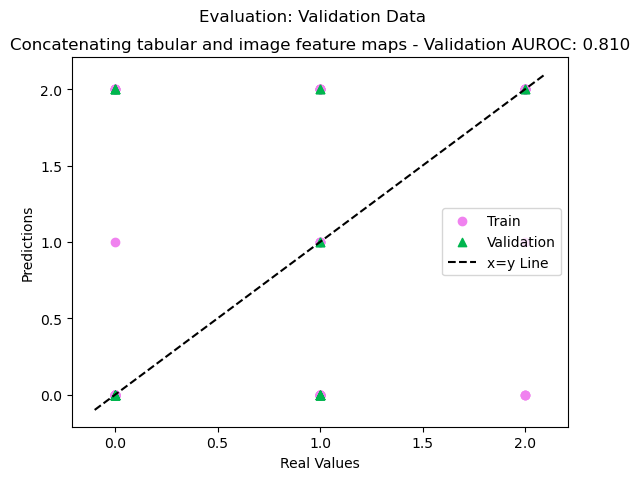

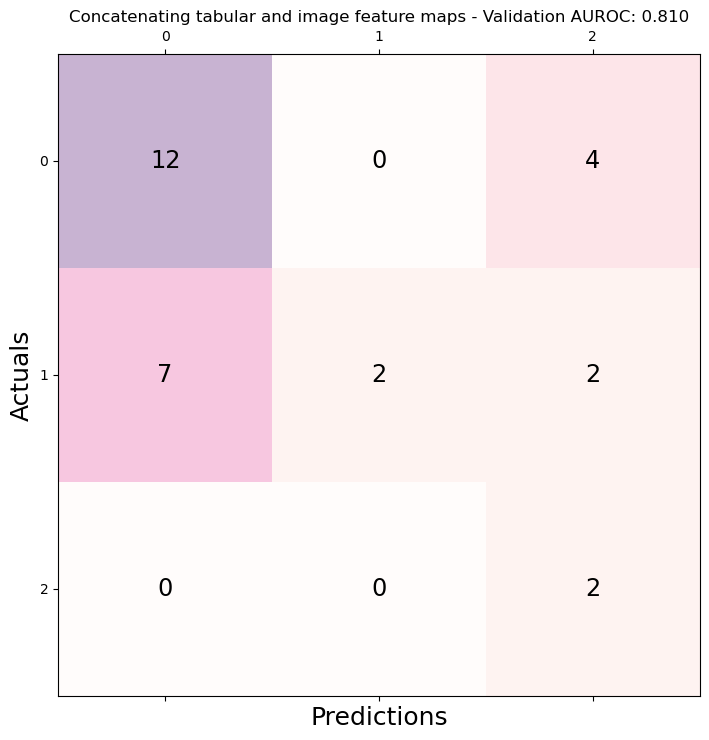

In [75]:
RealsVsPreds.from_final_val_data(trained_model)
ConfusionMatrix.from_final_val_data(trained_model)
plt.show()